In [1]:
import numba as nb
import numpy as np
import cv2
import yaml
import matplotlib.pyplot as plt
import cmasher
from collections import defaultdict
from pathlib import Path
from timeit import timeit

## Transform image

In [2]:
x_stage_mean = np.float32((68 + 115) / 2)
y_stage_mean = np.float32((47 + 113) / 2)

In [3]:
@nb.jit(nopython=True, fastmath=True)
def get_muscle_px_coords_jit2(
    x_stage,
    y_stage,
    row_behavior,
    col_behavior,
    w_mus_stagephys2px_x,
    w_mus_stagephys2px_y,
    w_beh_stagepx2phys_x,
    w_beh_stagepx2phys_y,
):
    input_beh_stagepx2phys = np.array([1, x_stage, y_stage, col_behavior, row_behavior])
    x_phys = np.dot(w_beh_stagepx2phys_x, input_beh_stagepx2phys)
    y_phys = np.dot(w_beh_stagepx2phys_y, input_beh_stagepx2phys)
    
    input_mus_stagephys2px = np.array([1, x_stage, y_stage, x_phys, y_phys])
    row_muscle = np.dot(w_mus_stagephys2px_y, input_mus_stagephys2px)
    col_muscle = np.dot(w_mus_stagephys2px_x, input_mus_stagephys2px) 

    return row_muscle, col_muscle

@nb.jit(nopython=True, parallel=True, nogil=True, fastmath=True)
def map_muscle_to_behavior_jit2(
    muscle_image,
    behavior_image_dim,
    x_stage,
    y_stage,
    w_mus_stagephys2px_x,
    w_mus_stagephys2px_y,
    w_beh_stagepx2phys_x,
    w_beh_stagepx2phys_y,
):
    mapped_muscle_image = np.full(behavior_image_dim, np.nan, dtype=muscle_image.dtype)
    for i in nb.prange(behavior_image_dim[0]):
        for j in range(behavior_image_dim[1]):
            muscle_i, muscle_j = get_muscle_px_coords_jit2(
                x_stage,
                y_stage,
                i,
                j,
                w_mus_stagephys2px_x,
                w_mus_stagephys2px_y,
                w_beh_stagepx2phys_x,
                w_beh_stagepx2phys_y,
            )
            muscle_i = int(muscle_i)
            muscle_j = int(muscle_j)
            if (
                0 <= muscle_i < muscle_image.shape[0]
                and 0 <= muscle_j < muscle_image.shape[1]
            ):
                mapped_muscle_image[i, j] = muscle_image[muscle_i, muscle_j]
    return mapped_muscle_image

In [4]:
class MuscleToBehaviorMapping2:
    def __init__(
        self,
        behavior_calibration_path: Path,
        muscle_calibration_path: Path,
        behavior_image_dim: tuple[int, int],
    ):
        """The MuscleToBehaviorMapping class is a wrapper for parameters
        fitted by fit_calibration_model.py. It can also be used to apply
        the transform defined by these parameters to warp the muscle image
        so that it is aligned with the behavior image.

        Args:
            behavior_calibration_params_path (Path):
                Path to the behavior camera calibration parameters. This
                file should be located at "metadata/calibration_parameters_behavior.yaml"
                under the recording directory (the path that you set in the
                GUI). This file is created by the recording GUI at the time
                of recording and is copied from "calibration/model/behavior_camera/"
                under the user profile folder **at the time of recording**
                (i.e., it might change after).
            muscle_calibration_params_path (Path):
                Path to the muscle camera calibration parameters. Same as
                above but replace "behavior" with "muscle" in paths.
            behavior_image_dim (tuple[int, int]):
                Dimensions of the behavior image as (nrows, ncols).
                This is used to create the output image after warping.
        """
        self.behavior_calibration_path = behavior_calibration_path
        self.muscle_calibration_path = muscle_calibration_path
        self.behavior_image_dim = behavior_image_dim
        params = {}
        with open(self.behavior_calibration_path, "r") as f:
            params["behavior_cam"] = yaml.safe_load(f)
        with open(self.muscle_calibration_path, "r") as f:
            params["muscle_cam"] = yaml.safe_load(f)

        input_keys = {
            "stagephys2px": [
                "bias",
                "stage_pos_x",
                "stage_pos_y",
                "physical_pos_x",
                "physical_pos_y",
            ],
            "stagepx2phys": [
                "bias",
                "stage_pos_x",
                "stage_pos_y",
                "pixel_pos_x",
                "pixel_pos_y",
            ],
        }
        transform_shorthands = {
            "stagephys2px": "stage_and_physical_to_pixel",
            "stagepx2phys": "stage_and_pixel_to_physical",
        }

        self.weight_vectors = defaultdict(dict)
        for target_cam in ["behavior_cam", "muscle_cam"]:
            self.weight_vectors[target_cam] = defaultdict(dict)
            for transform in ["stagephys2px", "stagepx2phys"]:
                self.weight_vectors[target_cam][transform] = {}
                for dim in ["x", "y"]:
                    trans = transform_shorthands[transform]
                    target_dim = f"{trans.split("_")[-1]}_pos_{dim}"
                    vec = np.zeros(len(input_keys[transform]))
                    for i, in_key in enumerate(input_keys[transform]):
                        vec[i] = params[target_cam][trans][target_dim][in_key]
                    self.weight_vectors[target_cam][transform][dim] = vec
                        
    def warp_muscle_image(self, muscle_image, x_stage, y_stage):
        return map_muscle_to_behavior_jit2(
            muscle_image,
            self.behavior_image_dim,
            x_stage,
            y_stage,
            self.weight_vectors["muscle_cam"]["stagephys2px"]["x"],
            self.weight_vectors["muscle_cam"]["stagephys2px"]["y"],
            self.weight_vectors["behavior_cam"]["stagepx2phys"]["x"],
            self.weight_vectors["behavior_cam"]["stagepx2phys"]["y"],
        )

In [5]:
behavior_calib_param_path = Path(
    "/home/sibwang/Data/spotlight/sibo_end/calibration/model/behavior_camera/calibration_result.yaml"
).expanduser()
muscle_calib_param_path = Path(
    "/home/sibwang/Data/spotlight/sibo_end/calibration/model/muscle_camera/calibration_result.yaml"
).expanduser()
mapping = MuscleToBehaviorMapping2(
    behavior_calib_param_path, muscle_calib_param_path, (1984, 1500)
)

In [6]:
behavior_image_example_path = Path(
    "/home/sibwang/Data/spotlight/sibo_end/calibration/aruco_scan/behavior_camera/aruco_scan_x68.00_y47.00.jpg"
)
muscle_image_example_path = Path(
    "/home/sibwang/Data/spotlight/sibo_end/calibration/aruco_scan/muscle_camera/aruco_scan_x68.00_y47.00.tif"
)

assert behavior_image_example_path.exists()
assert muscle_image_example_path.exists()

behavior_image_example = cv2.imread(str(behavior_image_example_path))
assert len(behavior_image_example.shape) == 3 and behavior_image_example.shape[2] == 3
behavior_image_example = behavior_image_example[:, :, 0]

muscle_image_example = cv2.imread(str(muscle_image_example_path), cv2.IMREAD_UNCHANGED)
assert len(muscle_image_example.shape) == 2
assert muscle_image_example.dtype == np.uint16
assert muscle_image_example.max() > 0

In [7]:
out = mapping.warp_muscle_image(muscle_image_example, x_stage_mean, y_stage_mean)

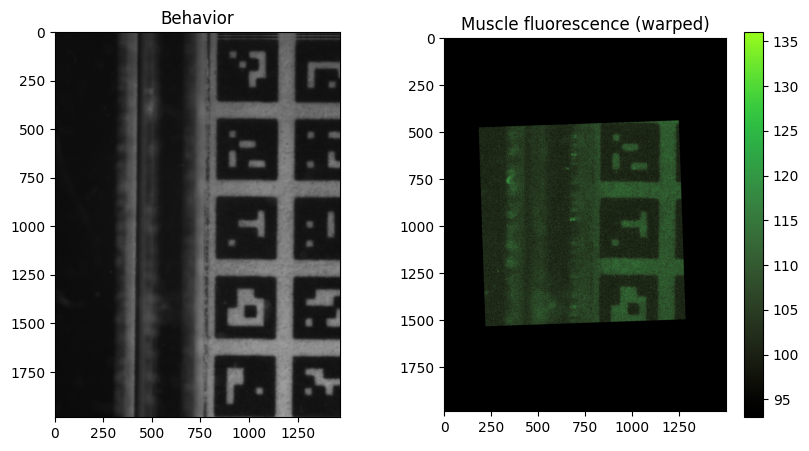

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(behavior_image_example, cmap="gray", vmin=0, vmax=255)
muscle_q1 = np.percentile(muscle_image_example.flatten(), 1)
muscle_q9999 = np.percentile(muscle_image_example.flatten(), 99.99)
muscle_plot = axes[1].imshow(
    out, cmap=cmasher.nuclear, vmin=muscle_q1, vmax=muscle_q9999
)
axes[0].set_title("Behavior")
axes[1].set_title("Muscle fluorescence (warped)")
plt.colorbar(muscle_plot)

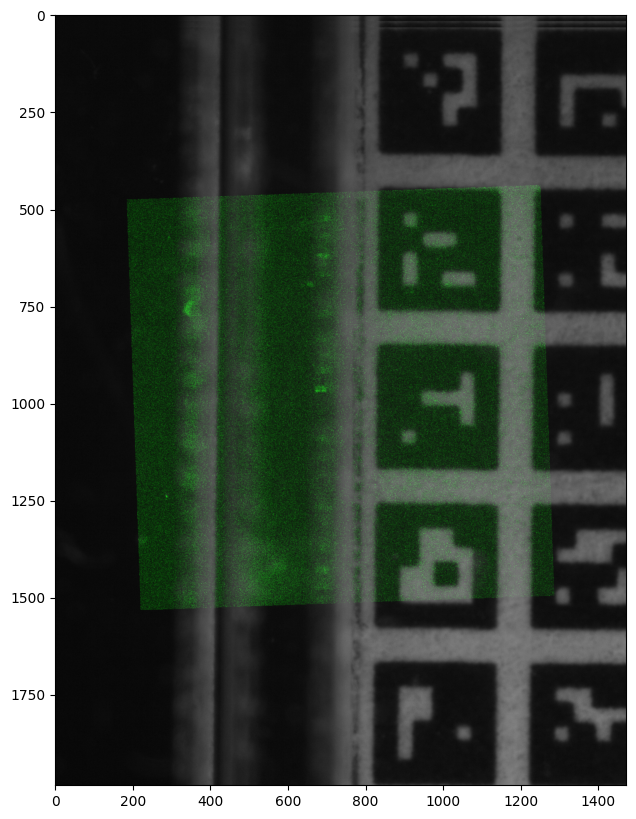

In [9]:
muscle_image_scaled = (out - muscle_q1) / (muscle_q9999 - muscle_q1)
muscle_image_scaled = np.clip(muscle_image_scaled, 0, 1) * 255

alpha = 0.8
behavior_image_rgb = np.repeat(behavior_image_example[:, :, np.newaxis], 3, axis=2)
muscle_image_rgb = np.zeros_like(behavior_image_rgb)
muscle_image_rgb[:, :, 1] = muscle_image_scaled[:, :1472]
overlaid = np.maximum(alpha * behavior_image_rgb, muscle_image_rgb).astype(np.uint8)
fig, ax = plt.subplots(figsize=(20, 10))
ax.imshow(overlaid, cmap="gray", vmin=0, vmax=255)

In [10]:
behavior_image_example_path = Path(
    "~/Data/spotlight/20250509-fly03-003-grade2/behavior_images/behavior_frame_000000000.jpg"
).expanduser()
muscle_image_example_path = Path(
    "~/Data/spotlight/20250509-fly03-003-grade2/muscle_images/muscle_frame_000000000.tif"
).expanduser()

assert behavior_image_example_path.exists()
assert muscle_image_example_path.exists()

behavior_image_example = cv2.imread(str(behavior_image_example_path))
assert len(behavior_image_example.shape) == 3 and behavior_image_example.shape[2] == 3
behavior_image_example = behavior_image_example[:, :, 0]

muscle_image_example = cv2.imread(str(muscle_image_example_path), cv2.IMREAD_UNCHANGED)
assert len(muscle_image_example.shape) == 2
assert muscle_image_example.dtype == np.uint16
assert muscle_image_example.max() > 0

In [11]:
out = mapping.warp_muscle_image(muscle_image_example, x_stage_mean, y_stage_mean)

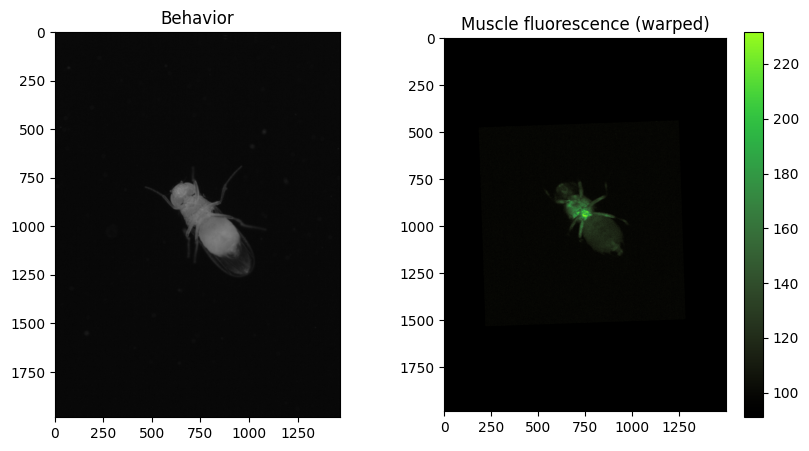

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(behavior_image_example, cmap="gray", vmin=0, vmax=255)
muscle_q1 = np.percentile(muscle_image_example.flatten(), 1)
muscle_q9999 = np.percentile(muscle_image_example.flatten(), 99.99)
muscle_plot = axes[1].imshow(
    out, cmap=cmasher.nuclear, vmin=muscle_q1, vmax=muscle_q9999
)
axes[0].set_title("Behavior")
axes[1].set_title("Muscle fluorescence (warped)")
plt.colorbar(muscle_plot)

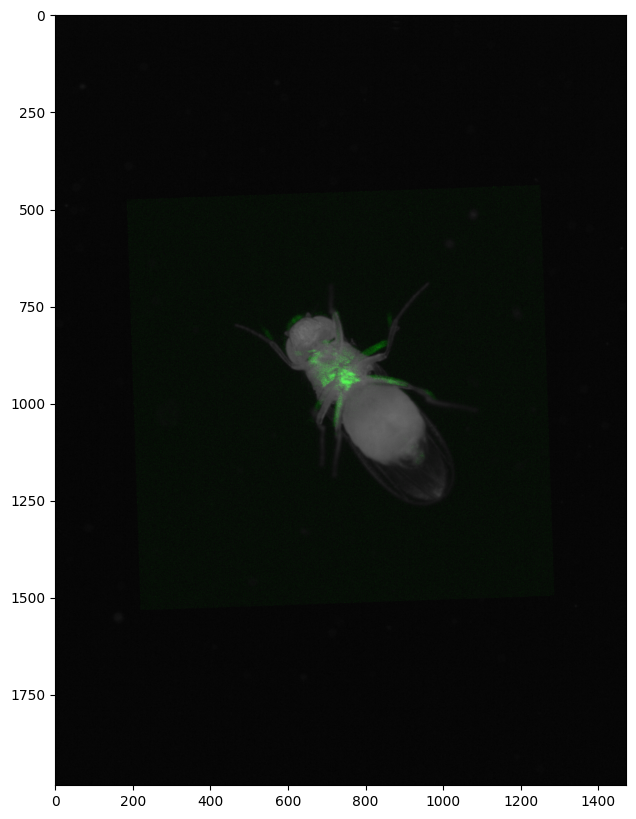

In [13]:
muscle_image_scaled = (out - muscle_q1) / (muscle_q9999 - muscle_q1)
muscle_image_scaled = np.clip(muscle_image_scaled, 0, 1) * 255

alpha = 0.8
behavior_image_rgb = np.repeat(behavior_image_example[:, :, np.newaxis], 3, axis=2)
muscle_image_rgb = np.zeros_like(behavior_image_rgb)
muscle_image_rgb[:, :, 1] = muscle_image_scaled[:, :1472]
overlaid = np.maximum(alpha * behavior_image_rgb, muscle_image_rgb).astype(np.uint8)
fig, ax = plt.subplots(figsize=(20, 10))
ax.imshow(overlaid, cmap="gray", vmin=0, vmax=255)